# Unsupervised Clustering Analysis

This notebook runs clustering experiments (KMeans, Gaussian Mixture, DBSCAN) on the extracted hive features, evaluates cluster quality, visualizes PCA embeddings, and saves model outputs for downstream interpretation.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.append(str(PROJECT_ROOT / 'src'))

from clustering import (
    load_feature_frame,
    run_experiments,
    save_clustering_outputs,
    summarize_cluster_distribution,
    plot_pca_scatter,
)

ASSIGNMENTS_PATH = PROJECT_ROOT / 'outputs' / 'models' / 'cluster_assignments.parquet'
METRICS_PATH = PROJECT_ROOT / 'outputs' / 'models' / 'cluster_metrics.csv'
FIG_DIR = PROJECT_ROOT / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
feature_df = load_feature_frame(
    audio_path=PROJECT_ROOT / 'outputs' / 'features' / 'audio_hourly_features.parquet',
    modulation_path=PROJECT_ROOT / 'outputs' / 'features' / 'modulation_hourly_features.parquet',
    multimodal_path=PROJECT_ROOT / 'outputs' / 'features' / 'multimodal_hourly_features.parquet',
)

print(f'Loaded feature rows: {len(feature_df)}')
print(f'Columns: {feature_df.shape[1]}')
feature_df.head()

Loaded feature rows: 1316
Columns: 264


,file_path,file_name,hive,timestamp_utc,date,hour,month_dir,day_dir,samplerate,duration_s,...,acc_f3_min,acc_f3_max,acc_f3_trend_per_hour,acc_m3_mean,acc_m3_std,acc_m3_min,acc_m3_max,acc_m3_trend_per_hour,has_sensor_data,has_accel_data
0,data\audio\hive_01\03\07\hive_01_20260307_1703...,hive_01_20260307_170323.flac,hive_01,2026-03-07 17:03:23+00:00,2026-03-07,17,3,7,16000,1800.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
1,data\audio\hive_01\03\07\hive_01_20260307_1733...,hive_01_20260307_173323.flac,hive_01,2026-03-07 17:33:23+00:00,2026-03-07,17,3,7,16000,1800.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
2,data\audio\hive_01\03\07\hive_01_20260307_1803...,hive_01_20260307_180323.flac,hive_01,2026-03-07 18:03:23+00:00,2026-03-07,18,3,7,16000,1800.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
3,data\audio\hive_01\03\07\hive_01_20260307_1833...,hive_01_20260307_183323.flac,hive_01,2026-03-07 18:33:23+00:00,2026-03-07,18,3,7,16000,1800.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False
4,data\audio\hive_01\03\07\hive_01_20260307_1903...,hive_01_20260307_190323.flac,hive_01,2026-03-07 19:03:23+00:00,2026-03-07,19,3,7,16000,1800.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False


In [3]:
assignments, metrics = run_experiments(
    feature_df,
    n_clusters=4,
    random_state=42,
    dbscan_eps=1.2,
    dbscan_min_samples=12,
)

save_clustering_outputs(assignments, metrics, assignments_path=ASSIGNMENTS_PATH, metrics_path=METRICS_PATH)

print(f'Saved assignments: {ASSIGNMENTS_PATH}')
print(f'Saved metrics: {METRICS_PATH}')

Saved assignments: c:\Users\Hashim Ali\Desktop\hive ai\outputs\models\cluster_assignments.parquet
Saved metrics: c:\Users\Hashim Ali\Desktop\hive ai\outputs\models\cluster_metrics.csv


In [4]:
metrics

,model,n_samples,n_clusters,n_noise,silhouette,davies_bouldin
0,kmeans,1316,4,0,0.322471,1.132947
1,gaussian_mixture,1316,4,0,0.319269,1.360903
2,dbscan,1316,0,1316,NaN,NaN


## PCA Visualizations

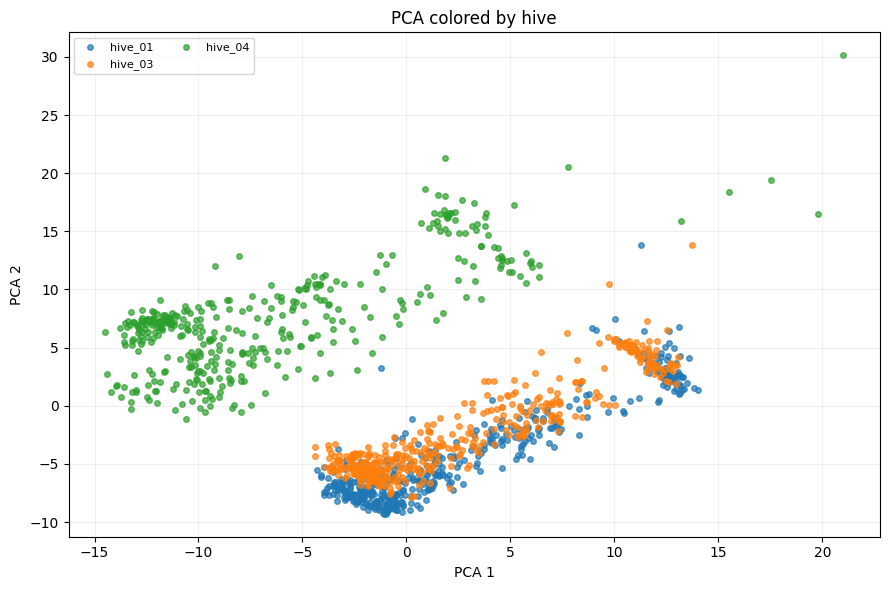

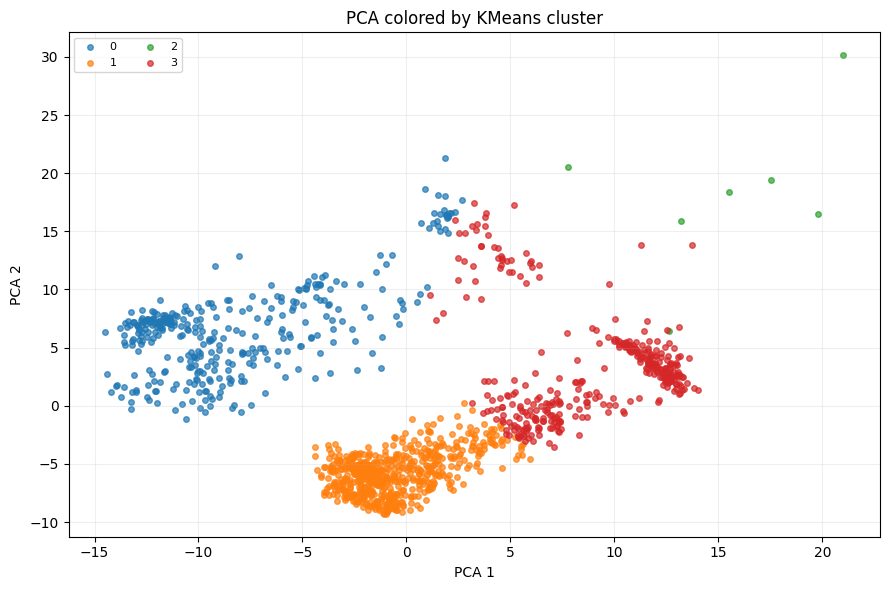

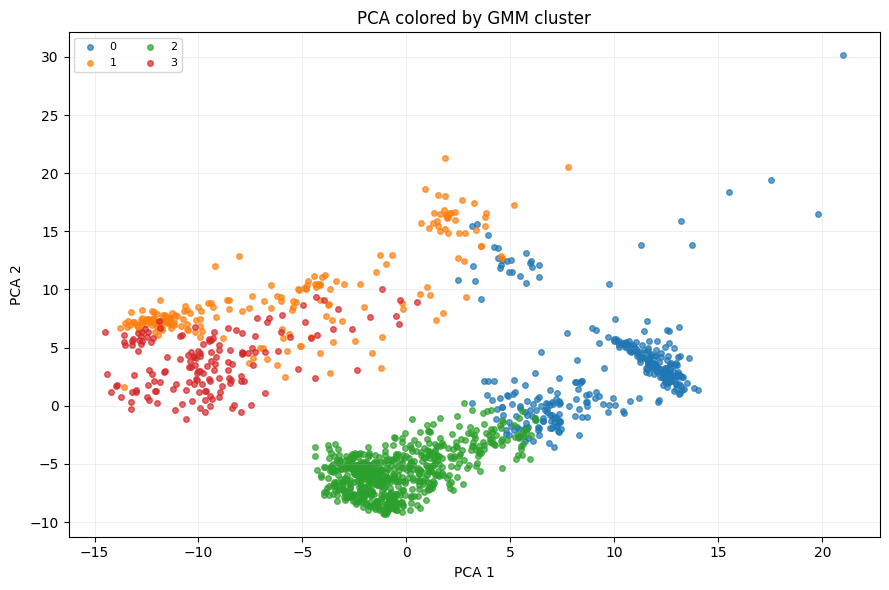

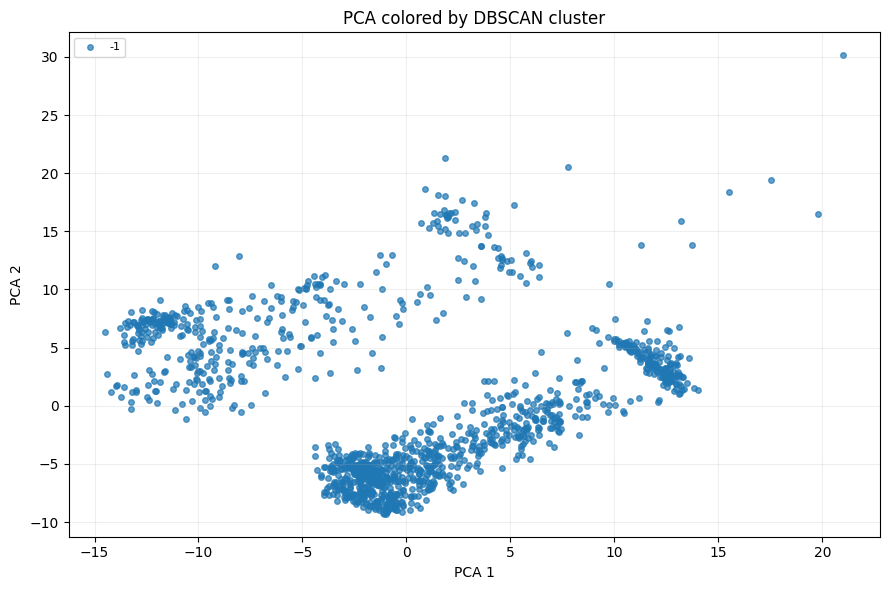

In [5]:
plot_pca_scatter(assignments, color_col='hive', title='PCA colored by hive', output_path=FIG_DIR / 'pca_by_hive.png')
plot_pca_scatter(assignments, color_col='cluster_kmeans', title='PCA colored by KMeans cluster', output_path=FIG_DIR / 'pca_by_kmeans_cluster.png')
plot_pca_scatter(assignments, color_col='cluster_gmm', title='PCA colored by GMM cluster', output_path=FIG_DIR / 'pca_by_gmm_cluster.png')
plot_pca_scatter(assignments, color_col='cluster_dbscan', title='PCA colored by DBSCAN cluster', output_path=FIG_DIR / 'pca_by_dbscan_cluster.png')

plt.show()

In [6]:
dist_kmeans = summarize_cluster_distribution(assignments, 'cluster_kmeans')
dist_gmm = summarize_cluster_distribution(assignments, 'cluster_gmm')
dist_dbscan = summarize_cluster_distribution(assignments, 'cluster_dbscan')

print('KMeans distribution by hive')
display(dist_kmeans.head(30))

print('GMM distribution by hive')
display(dist_gmm.head(30))

print('DBSCAN distribution by hive')
display(dist_dbscan.head(30))

KMeans distribution by hive


,hive,cluster_kmeans,count,pct_within_hive
0,hive_01,0,1,0.002165
1,hive_01,1,323,0.699134
2,hive_01,2,1,0.002165
3,hive_01,3,137,0.296537
4,hive_03,1,289,0.625541
5,hive_03,3,173,0.374459
6,hive_04,0,342,0.872449
7,hive_04,2,6,0.015306
8,hive_04,3,44,0.112245


GMM distribution by hive


,hive,cluster_gmm,count,pct_within_hive
0,hive_01,0,132,0.285714
1,hive_01,1,1,0.002165
2,hive_01,2,329,0.712121
3,hive_03,0,161,0.348485
4,hive_03,2,301,0.651515
5,hive_04,0,30,0.076531
6,hive_04,1,204,0.520408
7,hive_04,3,158,0.403061


DBSCAN distribution by hive


,hive,cluster_dbscan,count,pct_within_hive
0,hive_01,-1,462,1.0
1,hive_03,-1,462,1.0
2,hive_04,-1,392,1.0


In [8]:
assignments.head()

,file_path,file_name,hive,timestamp_utc,date,hour,cluster_kmeans,cluster_gmm,cluster_dbscan,pca_1,pca_2
0,data\audio\hive_01\03\07\hive_01_20260307_1703...,hive_01_20260307_170323.flac,hive_01,2026-03-07 17:03:23+00:00,2026-03-07,17,3,0,-1,10.476197,-0.597031
1,data\audio\hive_01\03\07\hive_01_20260307_1733...,hive_01_20260307_173323.flac,hive_01,2026-03-07 17:33:23+00:00,2026-03-07,17,1,2,-1,2.055777,-6.730562
2,data\audio\hive_01\03\07\hive_01_20260307_1803...,hive_01_20260307_180323.flac,hive_01,2026-03-07 18:03:23+00:00,2026-03-07,18,1,2,-1,0.487853,-8.540510
3,data\audio\hive_01\03\07\hive_01_20260307_1833...,hive_01_20260307_183323.flac,hive_01,2026-03-07 18:33:23+00:00,2026-03-07,18,1,2,-1,-0.594283,-8.903180
4,data\audio\hive_01\03\07\hive_01_20260307_1903...,hive_01_20260307_190323.flac,hive_01,2026-03-07 19:03:23+00:00,2026-03-07,19,1,2,-1,-0.828056,-8.874252


## DBSCAN Tuning Update

Use tuned DBSCAN settings discovered from parameter sweep on the full feature set (`eps=3.0`, `min_samples=5`) and rerun experiments.

In [11]:
assignments, metrics = run_experiments(
    feature_df,
    n_clusters=4,
    random_state=42,
    dbscan_eps=3.0,
    dbscan_min_samples=5,
)

save_clustering_outputs(assignments, metrics, assignments_path=ASSIGNMENTS_PATH, metrics_path=METRICS_PATH)

print('Updated metrics with tuned DBSCAN:')
display(metrics)

# Refresh distributions after tuned rerun
dist_kmeans = summarize_cluster_distribution(assignments, 'cluster_kmeans')
dist_gmm = summarize_cluster_distribution(assignments, 'cluster_gmm')
dist_dbscan = summarize_cluster_distribution(assignments, 'cluster_dbscan')

Updated metrics with tuned DBSCAN:


,model,n_samples,n_clusters,n_noise,silhouette,davies_bouldin
0,kmeans,1316,4,0,0.322471,1.132947
1,gaussian_mixture,1316,4,0,0.319269,1.360903
2,dbscan,1316,15,927,0.269768,0.850577


## Queenless-Window Hypothesis (Unsupervised)

Without labels, define candidate queenless windows as hours where a hive shows unusually large shifts in cluster composition compared with its own recent baseline.

Heuristic used:
1. Build hourly cluster distribution per hive (KMeans by default).
2. Compute change magnitude as total variation distance (TVD) between consecutive hours.
3. Compute rolling z-score of TVD within each hive.
4. Mark candidate windows where z-score >= 2.0 and keep top anomalies.

In [12]:
import numpy as np

if 'timestamp_utc' not in assignments.columns:
    raise ValueError('assignments must include timestamp_utc for temporal analysis')

work = assignments.copy()
work['timestamp_utc'] = pd.to_datetime(work['timestamp_utc'], utc=True, errors='coerce')
work = work.dropna(subset=['timestamp_utc', 'hive', 'cluster_kmeans'])
work['hour_bucket_utc'] = work['timestamp_utc'].dt.floor('h')

# Hourly cluster proportions by hive
hourly_counts = (
    work.groupby(['hive', 'hour_bucket_utc', 'cluster_kmeans'])
    .size()
    .rename('count')
    .reset_index()
)

hourly_totals = (
    hourly_counts.groupby(['hive', 'hour_bucket_utc'])['count']
    .sum()
    .rename('total')
    .reset_index()
)

hourly_props = hourly_counts.merge(hourly_totals, on=['hive', 'hour_bucket_utc'], how='left')
hourly_props['prop'] = hourly_props['count'] / hourly_props['total']

pivot = (
    hourly_props
    .pivot_table(index=['hive', 'hour_bucket_utc'], columns='cluster_kmeans', values='prop', fill_value=0.0)
    .sort_index()
)

# Total variation distance between consecutive hourly distributions
def compute_tvd(series_df: pd.DataFrame) -> pd.Series:
    values = series_df.to_numpy()
    tvd = [np.nan]
    for i in range(1, len(values)):
        tvd.append(0.5 * np.abs(values[i] - values[i - 1]).sum())
    return pd.Series(tvd, index=series_df.index)

anomaly_rows = []
for hive, frame in pivot.groupby(level=0):
    local = frame.droplevel(0)
    tvd = compute_tvd(local)
    rolling_mean = tvd.rolling(window=24, min_periods=6).mean()
    rolling_std = tvd.rolling(window=24, min_periods=6).std()
    z = (tvd - rolling_mean) / rolling_std.replace(0, np.nan)

    out = pd.DataFrame({
        'hive': hive,
        'hour_bucket_utc': local.index,
        'tvd': tvd.values,
        'tvd_zscore': z.values,
    })
    anomaly_rows.append(out)

queenless_candidates = pd.concat(anomaly_rows, ignore_index=True)
queenless_candidates['queenless_candidate'] = queenless_candidates['tvd_zscore'] >= 2.0
queenless_candidates = queenless_candidates.sort_values(['hive', 'hour_bucket_utc'])

QUEENLESS_PATH = PROJECT_ROOT / 'outputs' / 'models' / 'queenless_window_candidates.csv'
queenless_candidates.to_csv(QUEENLESS_PATH, index=False)

print(f'Saved candidate windows: {QUEENLESS_PATH}')
print('Candidate counts by hive:')
display(
    queenless_candidates.groupby('hive', dropna=False)['queenless_candidate'].sum().rename('n_candidates').reset_index()
)

print('Top candidate windows (highest z-score):')
display(
    queenless_candidates.dropna(subset=['tvd_zscore'])
    .sort_values('tvd_zscore', ascending=False)
    .head(20)
)

Saved candidate windows: c:\Users\Hashim Ali\Desktop\hive ai\outputs\models\queenless_window_candidates.csv
Candidate counts by hive:


,hive,n_candidates
0,hive_01,8
1,hive_03,13
2,hive_04,8


Top candidate windows (highest z-score):


,hive,hour_bucket_utc,tvd,tvd_zscore,queenless_candidate
560,hive_04,2026-03-13 02:00:00+00:00,1.0,4.694855,True
561,hive_04,2026-03-13 03:00:00+00:00,1.0,3.246793,True
22,hive_01,2026-03-08 15:00:00+00:00,1.0,2.694967,True
445,hive_03,2026-03-16 14:00:00+00:00,1.0,2.620857,True
520,hive_04,2026-03-11 10:00:00+00:00,0.5,2.590045,True
518,hive_04,2026-03-11 08:00:00+00:00,0.5,2.590045,True
517,hive_04,2026-03-11 07:00:00+00:00,0.5,2.590045,True
194,hive_01,2026-03-15 19:00:00+00:00,1.0,2.543374,True
418,hive_03,2026-03-15 11:00:00+00:00,1.0,2.543374,True
316,hive_03,2026-03-11 05:00:00+00:00,1.0,2.479189,True


## Interpretation Summary

Key observations from the tuned unsupervised run:

1. `KMeans` and `Gaussian Mixture` remain stable baselines with moderate separation (`silhouette` around 0.32).
2. Tuned `DBSCAN` now finds structure (`15` clusters) but still leaves substantial noise (`927/1316`, about `70%`), so it is better used as an anomaly detector than a primary partitioning model.
3. Queenless-window candidates are concentrated in short bursts rather than uniformly spread, with notable peaks in `hive_04` (highest z-scores) and recurring events in `hive_03`.
4. The strongest anomaly windows in this run are:
   - `hive_04` at `2026-03-13 02:00 UTC` (z-score `4.69`)
   - `hive_04` at `2026-03-13 03:00 UTC` (z-score `3.25`)
   - `hive_01` at `2026-03-08 15:00 UTC` (z-score `2.69`)

Practical interpretation:
- Treat these windows as high-priority inspection candidates, not confirmed queen-loss labels.
- For operational triage, use top-z-score windows first and cross-check with beekeeper notes or manual hive inspections.

In [13]:
top20_path = PROJECT_ROOT / 'outputs' / 'models' / 'queenless_top20.csv'
metrics_path = PROJECT_ROOT / 'outputs' / 'models' / 'cluster_metrics.csv'

top20 = pd.read_csv(top20_path)
metrics_latest = pd.read_csv(metrics_path)

print('Latest clustering metrics:')
display(metrics_latest)

print('Top candidate count by hive (top 20 table):')
display(top20.groupby('hive').size().rename('top20_count').reset_index())

print('Top 10 candidate windows:')
display(top20.head(10))

Latest clustering metrics:


,model,n_samples,n_clusters,n_noise,silhouette,davies_bouldin
0,kmeans,1316,4,0,0.322471,1.132947
1,gaussian_mixture,1316,4,0,0.319269,1.360903
2,dbscan,1316,15,927,0.269768,0.850577


Top candidate count by hive (top 20 table):


,hive,top20_count
0,hive_01,5
1,hive_03,9
2,hive_04,6


Top 10 candidate windows:


,hive,hour_bucket_utc,tvd,tvd_zscore,queenless_candidate
0,hive_04,2026-03-13 02:00:00+00:00,1.0,4.694855,True
1,hive_04,2026-03-13 03:00:00+00:00,1.0,3.246793,True
2,hive_01,2026-03-08 15:00:00+00:00,1.0,2.694967,True
3,hive_03,2026-03-16 14:00:00+00:00,1.0,2.620857,True
4,hive_04,2026-03-11 07:00:00+00:00,0.5,2.590045,True
5,hive_04,2026-03-11 10:00:00+00:00,0.5,2.590045,True
6,hive_04,2026-03-11 08:00:00+00:00,0.5,2.590045,True
7,hive_01,2026-03-15 19:00:00+00:00,1.0,2.543374,True
8,hive_03,2026-03-15 11:00:00+00:00,1.0,2.543374,True
9,hive_03,2026-03-11 05:00:00+00:00,1.0,2.479189,True
